# Блок заданий 04: бустинг

## Вспомогательный код

*(Можно не смотреть, но надо запустить)*

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
ok = set()  # это служебная структура, чтобы Вам было проще смотреть все ли задания выполнены
all_tasks = (
    {'1.1', '1.2'}
)

Код из прошлого занятия:

In [3]:
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from numbers import Real, Integral
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

# на случай, если версия sklearn отличается очень существенно используем такой хак:
try:
    from sklearn.base import _fit_context
    from sklearn.utils._param_validation import StrOptions, Interval
except:
    _fit_context = lambda **kwargs: lambda fn: fn
    StrOptions = lambda _: None

try:
    from sklearn.utils import check_X_y
except:
    check_X_y = lambda X, y: None


In [4]:
class StepFunctionRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        check_X_y(X, y)
        
        self.tree_ = DecisionTreeRegressor(max_depth=1)
        self.tree_.fit(X, y)
        return self

    def predict(self, X):
        return self.tree_.predict(X)


## Задания

### 1. Бустинг



#### 1.1. Бустинг ступенчатой функции для регрессии


**Задача:** реализуйте бустинг ступенчатых функций (используя готовую ступенчатую функцию `StepFunctionRegressor`), оптимизирующий MSE.

**Можно использовать только данную реализацию ступенчатой функции**.

Здесь генерируются искусственные данные для обучения:

In [5]:
boost_X_train = np.linspace(-10.0, 20.0, 1000).reshape((10, 25, 4)).transpose(2, 0, 1).reshape((-1, 1))
boost_y_train = (boost_X_train[:, 0] - 5.0) ** 2 + 1.0

boost_X_test = np.linspace(-11.0, 21.0, 100).reshape((5, 5, 4)).transpose(2, 0, 1).reshape((-1, 1))
boost_y_test = (boost_X_test[:, 0] - 5.0) ** 2 + 1.0


Реализация модели:

In [6]:
class StepFunctionBoostingRegressor(RegressorMixin, BaseEstimator):
    _parameter_constraints: dict = {
        "n_estimators": [Interval(Integral, 1, None, closed='left')],
        "gamma": [Interval(Real, 0.0, 1.0, closed='right')],
    }
    def __init__(self, n_estimators=100, gamma=0.9):
        self.n_estimators = n_estimators
        self.gamma = gamma

    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y):
        check_X_y(X, y)
        assert X.shape[1] == 1
        
        self.initial_ = np.mean(y)
        F = np.full_like(y, self.initial_)
        self.estimators_ = []
        for _ in range(self.n_estimators):
            r = y - F
            tree = StepFunctionRegressor()
            tree.fit(X, r)
            F += self.gamma * tree.predict(X)
            self.estimators_.append(tree)
        return self

    def predict(self, X):
        return self.initial_ + self.gamma * np.sum([est.predict(X) for est in self.estimators_], axis=0)


Создаём модель, затем обучаем:

In [7]:
step_boosting_regressor = StepFunctionBoostingRegressor()
step_boosting_regressor.fit(boost_X_train, boost_y_train)

,n_estimators,100
,gamma,0.9


In [17]:
# ваш код для проверки модели, если требуется

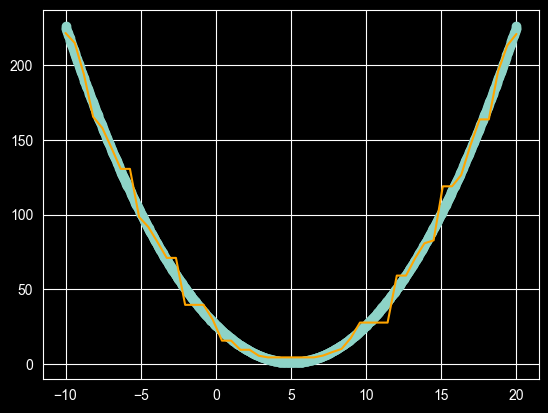

In [8]:
plt.scatter(boost_X_train[:, 0], boost_y_train)
t = np.linspace(-10., 20.)
plt.plot(t, step_boosting_regressor.predict(t[:, np.newaxis]), c='orange')

Проверки, что задание выполнено верно:

In [9]:
assert isinstance(step_boosting_regressor, StepFunctionBoostingRegressor), 'Модель должна быть нужного класса'
predictions = step_boosting_regressor.predict(boost_X_test)
assert predictions.shape[0] == boost_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert len(np.unique(predictions)) < 100, 'Модель должна быть ступенчатой, не больше 100 "ступенек"'
assert np.mean(np.abs(predictions - boost_y_test)) < 10.0, 'Модель должна быть достаточно точной'

ok.add('1.1')

#### 1.2. Бустинг ступенчатой функции для классификации

**Задача:** реализуйте бустинг ступенчатых функций (используя готовую ступенчатую функцию `StepFunctionRegressor`), оптимизирующий бинарную кросс-энтропию.

**Можно использовать только данную реализацию ступенчатой функции**.

Здесь генерируются искусственные данные для обучения:

In [10]:
rng_1_2 = np.random.RandomState(123)

clf_boost_X_train = np.linspace(-10.0, 20.0, 10000).reshape((100, 25, 4)).transpose(2, 0, 1).reshape((-1, 1))
clf_boost_y_train = np.where(
    rng_1_2.rand(clf_boost_X_train.shape[0]) <= np.tanh(0.01 * (clf_boost_X_train[:, 0] - 5.0) ** 2),
    1.0,
    0.0
)

clf_boost_X_test = np.linspace(-11.0, 21.0, 1000).reshape((50, 5, 4)).transpose(2, 0, 1).reshape((-1, 1))
clf_boost_y_test = np.where(
    rng_1_2.rand(clf_boost_X_test.shape[0]) <= np.tanh(0.01 * (clf_boost_X_test[:, 0] - 5.0) ** 2),
    1.0,
    0.0
)


Реализация модели:

In [11]:
from scipy.special import expit

In [28]:
class StepFunctionBoostingClassifier(ClassifierMixin, BaseEstimator):
    _parameter_constraints: dict = {
        "n_estimators": [Interval(Integral, 1, None, closed='left')],
        "gamma": [Interval(Real, 0.0, 1.0, closed='right')],
    }
    def __init__(self, n_estimators=100, gamma=0.9):
        self.n_estimators = n_estimators
        self.gamma = gamma

    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y):
        check_X_y(X, y)
        assert X.shape[1] == 1
        
        self.estimators_ = []
        F = np.zeros(len(y))
        for _ in range(self.n_estimators):
            p = expit(F)
            r = y - p
            tree = StepFunctionRegressor()
            tree.fit(X, r)
            F += self.gamma * tree.predict(X)
            self.estimators_.append(tree)
        return self

    def predict_proba(self, X):
        F = self.gamma * np.sum([est.predict(X) for est in self.estimators_], axis=0)
        return expit(F)

    def predict(self, X):
        return self.predict_proba(X) >= 0.5


Создаём модель, затем обучаем:

In [29]:
step_boosting_clf = StepFunctionBoostingClassifier()
step_boosting_clf.fit(clf_boost_X_train, clf_boost_y_train)

,n_estimators,100
,gamma,0.9


In [30]:
# ваш код для проверки модели, если требуется

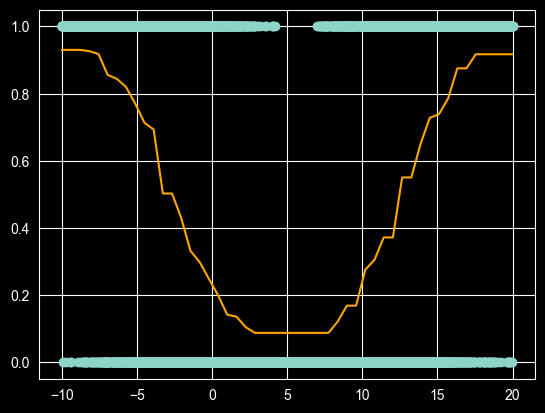

In [31]:
plt.scatter(clf_boost_X_train[:, 0], clf_boost_y_train)
t = np.linspace(-10., 20.)
plt.plot(t, step_boosting_clf.predict_proba(t[:, np.newaxis]), c='orange')

Проверки, что задание выполнено верно:

In [32]:
assert isinstance(step_boosting_clf, StepFunctionBoostingClassifier), 'Модель должна быть нужного класса'
predictions = step_boosting_clf.predict_proba(clf_boost_X_test)
assert predictions.shape[0] == clf_boost_X_test.shape[0], 'Модель должна возвращать верное число предсказаний'
assert not np.allclose(predictions[:-1], predictions[1:]), 'Модель не должна возвращать константу'
assert len(np.unique(predictions)) < 100, 'Модель должна быть ступенчатой, не больше 100 "ступенек"'
assert roc_auc_score(clf_boost_y_test, predictions) > 0.9, 'Модель должна быть достаточно точной'

ok.add('1.2')

## Итоги

In [33]:
print(f'Выполнены задания: {ok}')
print(f'Осталось: {all_tasks - ok}')
print(f'Выполнено: {len(ok)}. Не выполнено: {len(all_tasks - ok)}')

Выполнены задания: {'1.1', '1.2'}
Осталось: set()
Выполнено: 2. Не выполнено: 0
